In [219]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll, make_moons

In [220]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [221]:
def get_swiss_roll(n_samples=5000):
    # Generate 3D swiss roll, but we only extract 2 dimensions to make it a 2D spiral
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.2)
    data = data[:, [0, 2]]
    # Standardize data to have zero mean and reasonable variance
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

In [222]:
def get_two_moons(n_samples=5000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

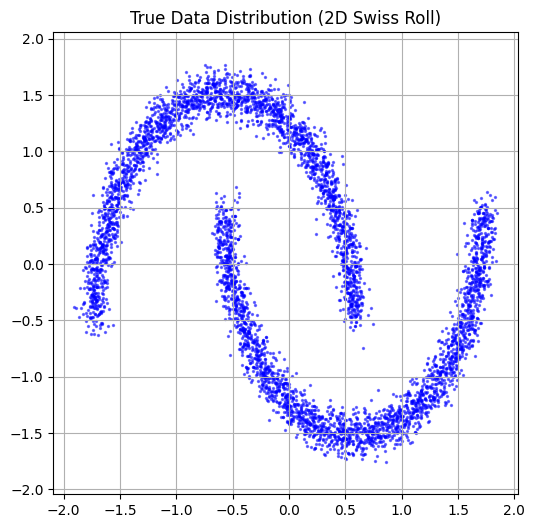

In [223]:
# dataset = get_swiss_roll(5000)
dataset = get_two_moons(5000)


plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
plt.title("True Data Distribution (2D Swiss Roll)")
plt.axis('equal')
plt.grid(True)
plt.show()

In [224]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Input is 3-dimensional: 2D coordinate + 1D scalar sigma
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(), # Softplus ensures smooth second derivatives for score matching
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2) # Output is a 2D vector (the score)
        )
        
    def forward(self, x, sigma):
        # x shape: [batch_size, 2]
        # sigma shape: [batch_size, 1]
        inputs = torch.cat([x, sigma], dim=-1)
        return self.net(inputs)

In [284]:
L = 30                 # Number of noise scales
sigma_1 = 1.0           # High noise (blankets the empty canvas space)
sigma_L = 0.01          # Low noise (resolves fine structure)

In [285]:
# Calculate geometric progression base gamma
def make_schedule(sigma_1, sigma_L, L):
    gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
    return torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

In [286]:
sigmas = make_schedule(sigma_1, sigma_L, L)

In [282]:
print("Noise Schedule (sigmas):")
for idx, s in enumerate(sigmas):
    print(f"Level {idx+1}: {s.item():.4f}")

Noise Schedule (sigmas):
Level 1: 2.0000
Level 2: 1.1101
Level 3: 0.6162
Level 4: 0.3420
Level 5: 0.1898
Level 6: 0.1054
Level 7: 0.0585
Level 8: 0.0325
Level 9: 0.0180
Level 10: 0.0100


In [271]:
def train_network(sigmas):

    network = ScoreNetwork(hidden_dim=128)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    epochs = 30000
    batch_size = 128

    for epoch in range(epochs):
    # 1. Sample a clean batch of data
        idx = torch.randint(0, len(dataset), (batch_size,))
        x_clean = dataset[idx]
        
        # 2. Randomly sample an index for the noise schedule per batch item
        noise_idx = torch.randint(0, L, (batch_size,))
        sigma = sigmas[noise_idx].unsqueeze(-1) # Shape: [batch_size, 1]
        
        # 3. Sample pure Gaussian noise
        z = torch.randn_like(x_clean)
        
        # 4. Create the perturbed noisy data
        x_noisy = x_clean + sigma * z
        
        # 5. Compute true analytical score target: -z / sigma
        target_score = -z / sigma
        
        # 6. Forward pass through network
        predicted_score = network(x_noisy, sigma)
        
        # 7. Weighted MSE Loss (scaled by sigma^2 to prevent high noise from drowning out low noise)
        loss = 0.5 * torch.mean(sigma**2 * torch.sum((predicted_score - target_score) ** 2, dim=-1))
        
        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 400 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")
    
    return network

In [272]:
network = train_network(sigmas)

Epoch [400/30000] | Loss: 323.3128
Epoch [800/30000] | Loss: 532.4647
Epoch [1200/30000] | Loss: 283.9034
Epoch [1600/30000] | Loss: 628.6637
Epoch [2000/30000] | Loss: 389.4890
Epoch [2400/30000] | Loss: 220.6693
Epoch [2800/30000] | Loss: 433.2783
Epoch [3200/30000] | Loss: 378.3710
Epoch [3600/30000] | Loss: 544.8643
Epoch [4000/30000] | Loss: 553.3253
Epoch [4400/30000] | Loss: 313.2135
Epoch [4800/30000] | Loss: 439.5020
Epoch [5200/30000] | Loss: 319.2037
Epoch [5600/30000] | Loss: 400.2759
Epoch [6000/30000] | Loss: 195.9949
Epoch [6400/30000] | Loss: 472.9276
Epoch [6800/30000] | Loss: 474.3129
Epoch [7200/30000] | Loss: 250.1117
Epoch [7600/30000] | Loss: 508.4316
Epoch [8000/30000] | Loss: 555.8843
Epoch [8400/30000] | Loss: 563.6698
Epoch [8800/30000] | Loss: 566.9548
Epoch [9200/30000] | Loss: 455.9687
Epoch [9600/30000] | Loss: 405.0033
Epoch [10000/30000] | Loss: 477.0472
Epoch [10400/30000] | Loss: 455.9925
Epoch [10800/30000] | Loss: 395.3543
Epoch [11200/30000] | Loss:

In [273]:
def sample_annealed_langevin(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    with torch.no_grad():
        # Start from a broad Gaussian distribution matching our highest noise scale
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Outer Loop: Walk down through the noise levels from highest to lowest
        for i, sigma in enumerate(sigmas):
            # Compute step size dynamically scaled for this level
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            # Inner Loop: Run Langevin Dynamics for T steps at this noise level
            for t in range(T):
                # 1. Get the score vector field from our network
                score = network(x, sigma_tensor)
                
                # 2. Add fresh noise for the random shake
                z = torch.randn_like(x)
                
                # 3. Update equation
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
    return x.numpy()

In [274]:
generated_samples = sample_annealed_langevin(network, sigmas, n_samples=5000, T=100)

In [311]:
def plot_samples(dataset, generated_samples, title, plot_true=True):
    # 1. Dynamically set the number of columns based on plot_true
    n_cols = 2 if plot_true else 1
    
    # Adjust the overall figure width depending on the number of plots
    fig_width = 12 if plot_true else 6
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, 6))

    # 2. If n_cols == 1, Matplotlib returns a single Axis object instead of a list/array.
    # To keep our indexing code uniform, we wrap it in a list if it isn't one.
    if n_cols == 1:
        axes = [axes]

    axis_idx = 0

    # 3. Plot True Data (only if requested)
    if plot_true:
        axes[axis_idx].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
        axes[axis_idx].set_title("True Training Data")
        axes[axis_idx].set_xlim(-2.5, 2.5)
        axes[axis_idx].set_ylim(-2.5, 2.5)
        axes[axis_idx].grid(True)
        axis_idx += 1  # Move to the next plot slot

    # 4. Plot Generated Data
    axes[axis_idx].scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, color='#a1112a')
    axes[axis_idx].set_title(title)
    axes[axis_idx].set_xlim(-2.5, 2.5)
    axes[axis_idx].set_ylim(-2.5, 2.5)
    axes[axis_idx].grid(True)

    plt.tight_layout() # Ensures labels don't overlap boundaries nicely
    plt.show()
    

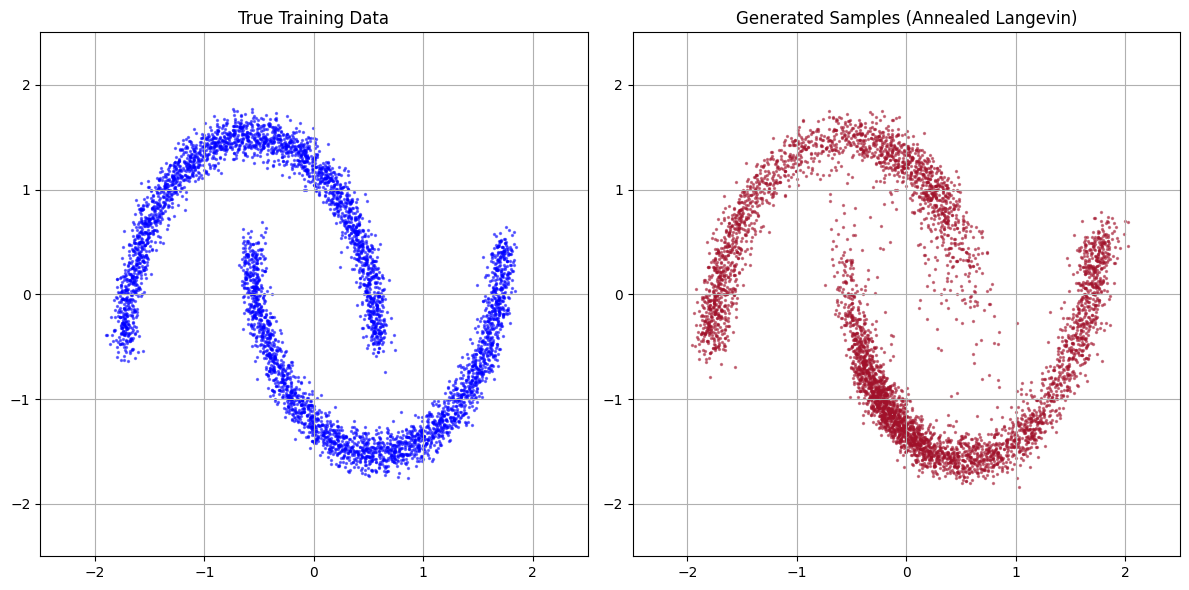

In [312]:
plot_samples(dataset, generated_samples, "Generated Samples (Annealed Langevin)", True)

### varying T, fixed L

In [268]:
samples_bad  = sample_annealed_langevin(network, sigmas, n_samples=3000, T=2)
samples_good = sample_annealed_langevin(network, sigmas, n_samples=3000, T=50)
samples_best = sample_annealed_langevin(network, sigmas, n_samples=3000, T=200)

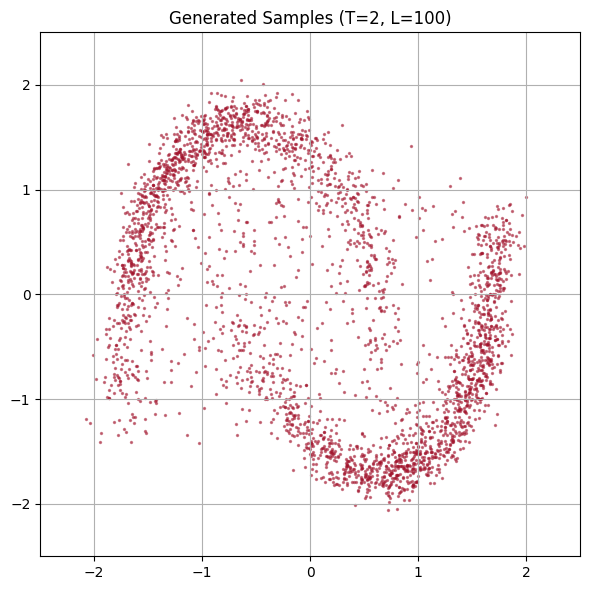

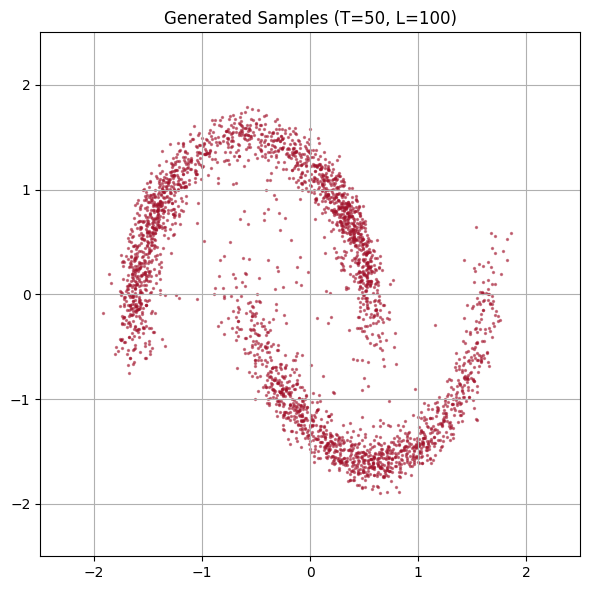

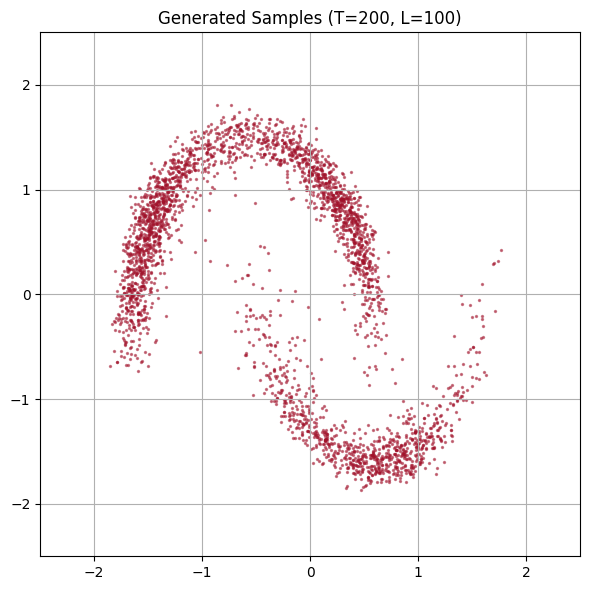

In [313]:
plot_samples(dataset, samples_bad, "Generated Samples (T=2, L=100)", False)
plot_samples(dataset, samples_good, "Generated Samples (T=50, L=100)", False)
plot_samples(dataset, samples_best, "Generated Samples (T=200, L=100)", False)

### varying L fixed T

In [326]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples = {}
SIGMA_1 = 1.0
SIGMA_L = 0.01
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    samples        = sample_annealed_langevin(network, sched, 3000, T=100)
    all_samples[L] = samples
    valid = int(np.isfinite(samples).all(axis=1).sum())
    print(f"L={L:<3}  T={100}")

L=10   T=100
L=20   T=100
L=30   T=100
L=40   T=100
L=50   T=100


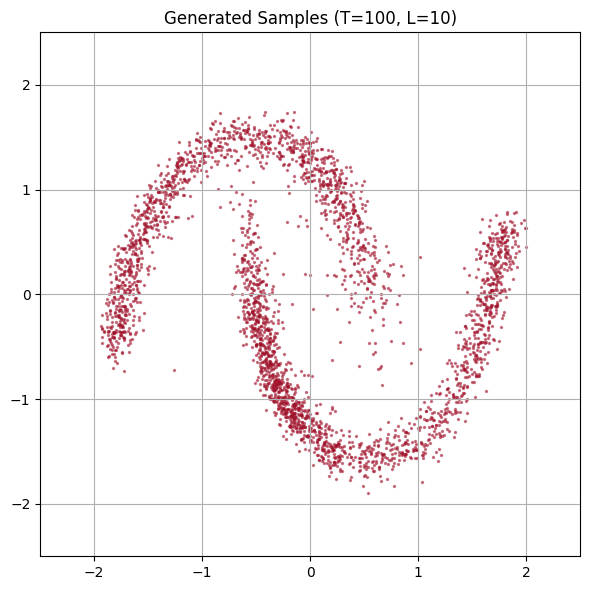

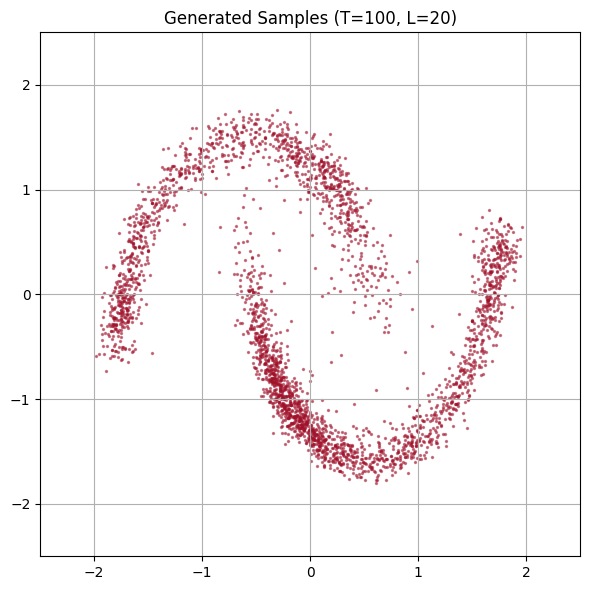

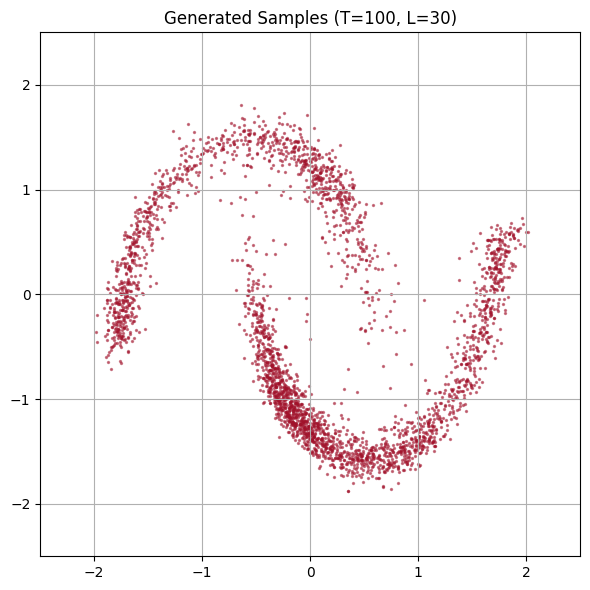

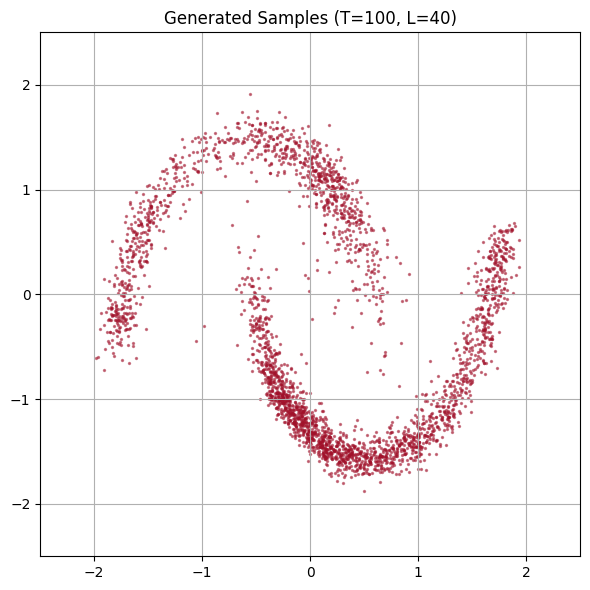

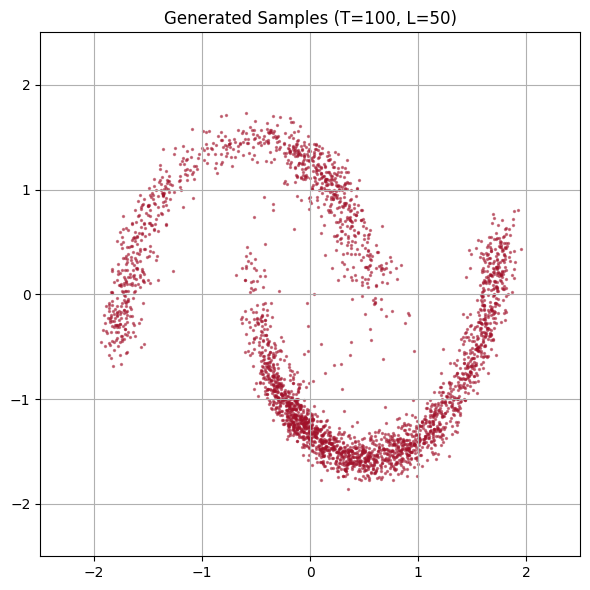

In [327]:
L_SWEEP    = [10, 20, 30, 40, 50]
for L in L_SWEEP:
    plot_samples(dataset, all_samples[L], f"Generated Samples (T=100, L={L})", False)

### score field plot

In [235]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
    """
    Plots the score vector field at a specific noise level index.
    - level_idx: choose which index of the sigmas array to visualize (e.g., 0 to L-1)
    - grid_res: controls how dense the grid of arrows is (20 to 30 is ideal)
    """
    network.eval()
    sigma_val = sigmas[level_idx].item()
    
    # 1. Create a uniform 2D grid covering your data range
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Flatten the grid coordinates to feed into PyTorch
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # 2. Create the scalar sigma tensor matching the batch size of the grid
    sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
    # 3. Predict the score arrows
    with torch.no_grad():
        # Shape: [grid_res * grid_res, 2]
        predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
    # Reshape vectors back into a 2D grid structure for plotting
    U = predicted_scores[:, 0].reshape(X.shape)
    V = predicted_scores[:, 1].reshape(Y.shape)
    
    
    # 4. Compute magnitudes to visually color-code strong vs weak forces
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plotting
    plt.figure(figsize=(6, 6))
    
    # Underlay a subset of the true data points for reference
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
    # Draw the vector arrows
    # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
    quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
                        angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
    plt.colorbar(quiver, label='Score Vector Magnitude')
    plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.xlim(-2.7, 2.7)
    plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

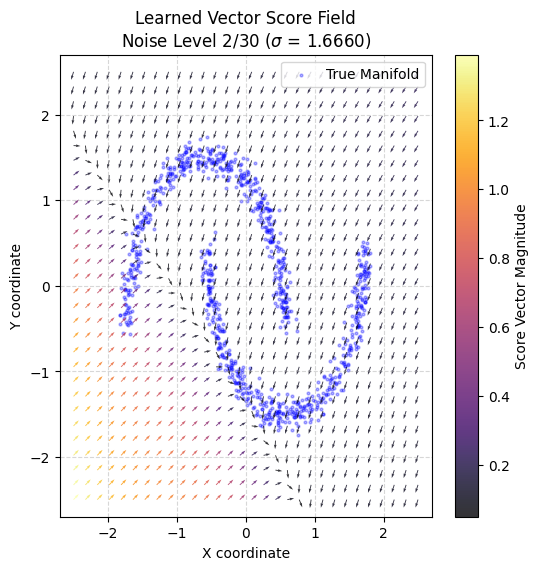

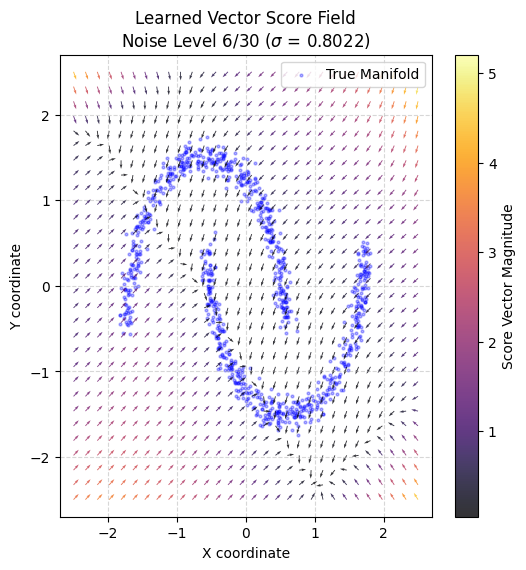

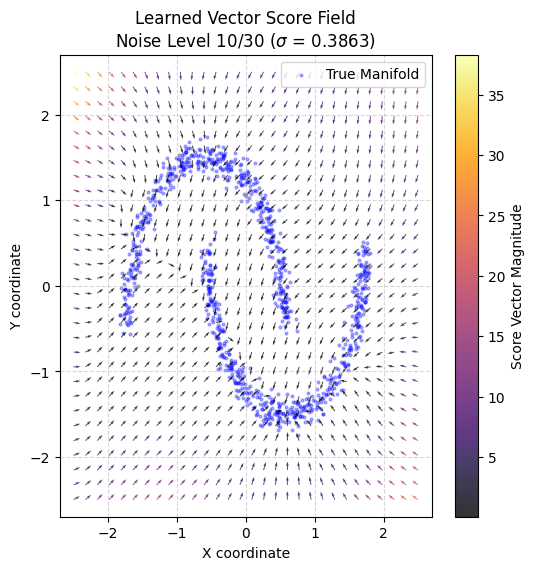

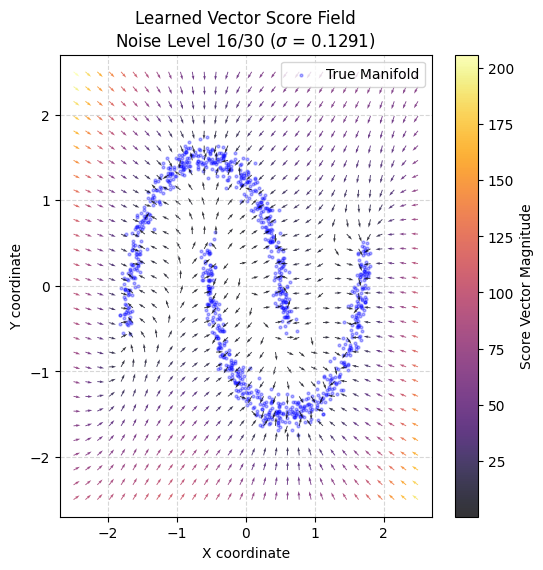

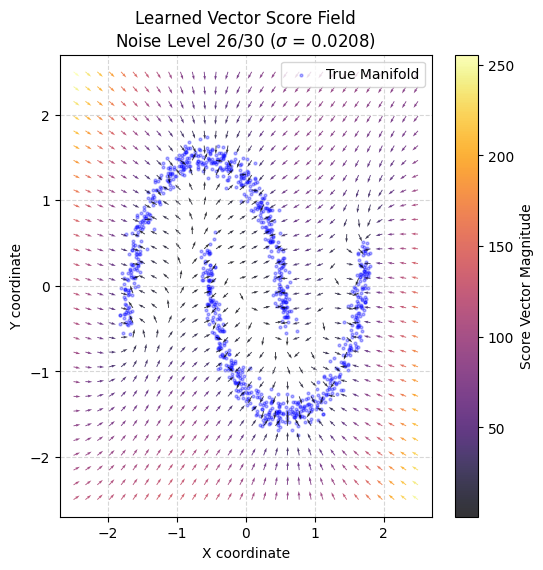

In [264]:
plot_score_field_grid(network, sigmas, dataset, level_idx=1, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=9, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=15, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=25, grid_res=30)

In [ ]:
# def visualize_langevin_evolution(network, sigmas, dataset, n_samples=600, T=100, eps=0.0001):
#     network.eval()
#     L_total = len(sigmas)
    
#     # Select 4 evenly spaced noise levels to visualize the evolution milestones
#     milestone_indices = [0, int(L_total * 0.25), int(L_total * 0.6), L_total - 1]
    
#     # Initialize the particle positions at the maximum noise level
#     x = torch.randn(n_samples, 2) * sigmas[0]
    
#     # Set up a 2x4 grid plot (Top row: Vector Fields | Bottom row: Moving Particles)
#     fig, axes = plt.subplots(2, 4, figsize=(20, 10))
#     col_idx = 0
    
#     # Setup uniform grid arrays for drawing underlying arrows
#     grid_res = 20
#     x_range = np.linspace(-2.5, 2.5, grid_res)
#     y_range = np.linspace(-2.5, 2.5, grid_res)
#     X, Y = np.meshgrid(x_range, y_range)
#     grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
#     grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

#     with torch.no_grad():
#         # Outer Loop: Walk down through the noise levels
#         for idx, sigma in enumerate(sigmas):
#             alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
#             sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
#             # If we hit a milestone, generate and plot the background vector field map FIRST
#             if idx in milestone_indices:
#                 grid_sigma = torch.full((grid_tensor.shape[0], 1), sigma.item())
#                 grid_scores = network(grid_tensor, grid_sigma).numpy()
#                 U = grid_scores[:, 0].reshape(X.shape)
#                 V = grid_scores[:, 1].reshape(Y.shape)

#                 eps_stable = 1e-8
#                 norms = np.sqrt(U**2 + V**2) + eps_stable
#                 U_norm = U / norms
#                 V_norm = V / norms

#                 # Plot using the normalized components (U_norm, V_norm)
#                 ax_top = axes[0, col_idx]
#                 ax_top.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.6, angles='xy', scale_units='xy', scale=12) # Lower scale = slightly longer arrows
                
#                 # Plot the background vector field (Top Row)
#                 # ax_top = axes[0, col_idx]
#                 # ax_top.quiver(X, Y, U, V, color='gray', alpha=0.6, angles='xy', scale_units='xy', scale=20)
#                 ax_top.scatter(dataset[:300, 0], dataset[:300, 1], s=2, color='blue', alpha=0.2)
#                 ax_top.set_title(f"Stage {col_idx+1}: Score Field ($sigma$={sigma.item():.3f})")
#                 ax_top.set_xlim(-2.7, 2.7)
#                 ax_top.set_ylim(-2.7, 2.7)
#                 ax_top.grid(True, alpha=0.3)
            
#             # Inner Loop: Run Langevin Dynamics for T steps at this noise level
#             for t in range(T):
#                 score = network(x, sigma_tensor)
#                 z = torch.randn_like(x)
#                 x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
#             # If we hit a milestone, snapshot where the particles have traveled (Bottom Row)
#             if idx in milestone_indices:
#                 ax_bottom = axes[1, col_idx]
                
#                 # NEW: Safe conversion of tracking tensors to raw plot coordinates
#                 x_numpy = x.detach().cpu().numpy()
                
#                 # Plot the red generated particles
#                 ax_bottom.scatter(x_numpy[:, 0], x_numpy[:, 1], s=3, color='red', alpha=0.6)
#                 ax_bottom.set_title(f"Particle Positions (End of Scale)")
#                 ax_bottom.set_xlim(-2.7, 2.7)
#                 ax_bottom.set_ylim(-2.7, 2.7)
#                 ax_bottom.grid(True, alpha=0.3)
#                 col_idx += 1
                
#     plt.tight_layout()
#     plt.show()

In [ ]:
# visualize_langevin_evolution(network, sigmas, dataset, n_samples=1000, T=80, eps=0.0001)

### comparing generated data with true data using Wasserstein distance

In [239]:
from scipy.stats import wasserstein_distance

In [ ]:


# # 1. Strip gradients, push to CPU, and cast to 64-bit float NumPy arrays
# clean_data_np = dataset[:1500].detach().cpu().numpy()
# generated_np = torch.tensor(generated_samples).detach().cpu().numpy() # ensure it's a tensor first if needed

# # 2. Extract specific 1D coordinate arrays
# true_x = clean_data_np[:, 0]
# true_y = clean_data_np[:, 1]

# gen_x = generated_np[:, 0]
# gen_y = generated_np[:, 1]



In [ ]:
# # 3. Strip out any rows containing NaN or Infinity from the generated coordinates
# valid_mask = np.isfinite(gen_x) & np.isfinite(gen_y)
# gen_x_clean = gen_x[valid_mask]
# gen_y_clean = gen_y[valid_mask]

# # 4. Defensive check: Calculate only if we have remaining valid points
# if len(gen_x_clean) > 0:
#     wd_x = wasserstein_distance(true_x, gen_x_clean)
#     wd_y = wasserstein_distance(true_y, gen_y_clean)
#     sample_quality_score = wd_x + wd_y
#     print(f"Sample Quality Score (Wasserstein): {sample_quality_score:.4f} (Valid points: {len(gen_x_clean)}/{len(gen_x)})")
# else:
#     print("Warning: All generated samples exploded into NaNs. Reduce your sampling step size 'eps'!")

Sample Quality Score (Wasserstein): 0.2559 (Valid points: 2000/2000)


In [ ]:
# import numpy as np
# from scipy.stats import wasserstein_distance

# # Sample two completely independent batches of TRUE clean data
# true_batch_1 = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
# true_batch_2 = dataset[torch.randint(0, len(dataset), (1500,))].numpy()

# # Calculate the distance between true data and itself
# base_x = wasserstein_distance(true_batch_1[:, 0], true_batch_2[:, 0])
# base_y = wasserstein_distance(true_batch_1[:, 1], true_batch_2[:, 1])
# perfect_score = base_x + base_y

# print(f"Theoretical 'Perfect' Score Limit: {perfect_score:.4f}")

Theoretical 'Perfect' Score Limit: 0.0457


In [330]:
def wasserstein_score(samples, dataset, n_real=1500):
    # print(len(samples))
    real = dataset[:n_real].numpy()
    mask = np.isfinite(samples).all(axis=1)
    # print(mask)
    s    = samples[mask]
    # print(s)
    if len(s) == 0:
        return float("inf"), 0
    wd = (wasserstein_distance(real[:, 0], s[:, 0]) +
          wasserstein_distance(real[:, 1], s[:, 1]))
    return wd, int(mask.sum())

# Theoretical floor
tb1   = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
tb2   = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
floor = (wasserstein_distance(tb1[:, 0], tb2[:, 0]) +
         wasserstein_distance(tb1[:, 1], tb2[:, 1]))
print(f"Theoretical floor (real vs real): {floor:.4f}")
print()

results = {}
header  = f"  L    T    WD Score   Valid"
print(header)
print("-" * len(header))
for L in L_SWEEP:
    wd, valid = wasserstein_score(all_samples[L], dataset)
    results[L] = wd
    marker = "  <- baseline" if L == 10 else ""
    print(f"  {L:<4} {100:<4} {wd:<10.4f} {valid}/{len(samples)}{marker}")

Theoretical floor (real vs real): 0.0886

  L    T    WD Score   Valid
----------------------------
  10   100  0.1817     3000/3000  <- baseline
  20   100  0.3023     3000/3000
  30   100  0.4275     3000/3000
  40   100  0.4971     3000/3000
  50   100  0.6834     3000/3000


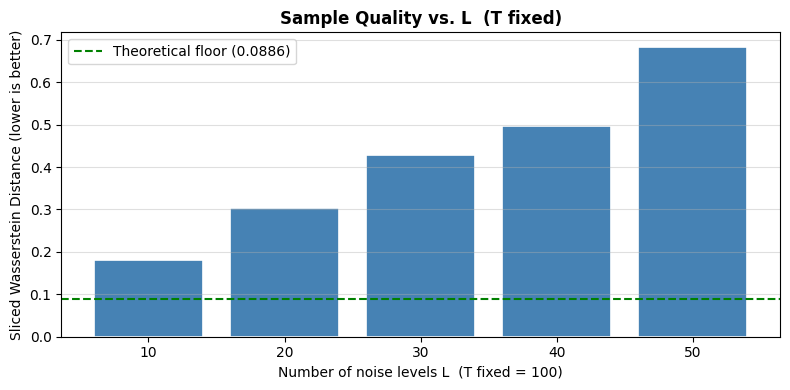

In [332]:
x_pos  = list(range(len(L_SWEEP)))
labels = [str(L) for L in L_SWEEP]
scores = [results[L] for L in L_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="steelblue", edgecolor="white", linewidth=1.2)
ax.axhline(floor, color="green", linestyle="--", lw=1.5,
           label=f"Theoretical floor ({floor:.4f})")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of noise levels L  (T fixed = {100})")
ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()